# Notebook 05: p_censoring

Loads interaction-feature data, creates an out-of-fold censoring probability feature, and saves output for the location-encoding stage.

## 1. Notebook set-up

In [1]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import DATA_DIR, PIPELINE_COLORS, PIPELINE_RESULTS_PATH

## 2. Data loading

In [2]:
in_path = DATA_DIR / '04-interaction-features.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 04-interaction-features.ipynb ' + 
         'first to generate data/04-interaction-features.csv.')
    )

housing_df = pd.read_csv(in_path)
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/fsa-feature-engineering-challenge/04-interaction-features.csv


## 3. Censoring model

In [3]:
y_censored = (housing_df['MedHouseVal'] >= 5.0).astype(int)
base_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
clf = LogisticRegression(max_iter=1000, random_state=315)

## 4. Add censoring probability feature

In [4]:
p_censored_oof = cross_val_predict(
    clf,
    housing_df[base_features],
    y_censored,
    cv=10,
    method='predict_proba'
)[:, 1]

housing_df['p_censored'] = p_censored_oof
print('Added p_censored OOF feature.')

Added p_censored OOF feature.


## 5. Performance evaluation

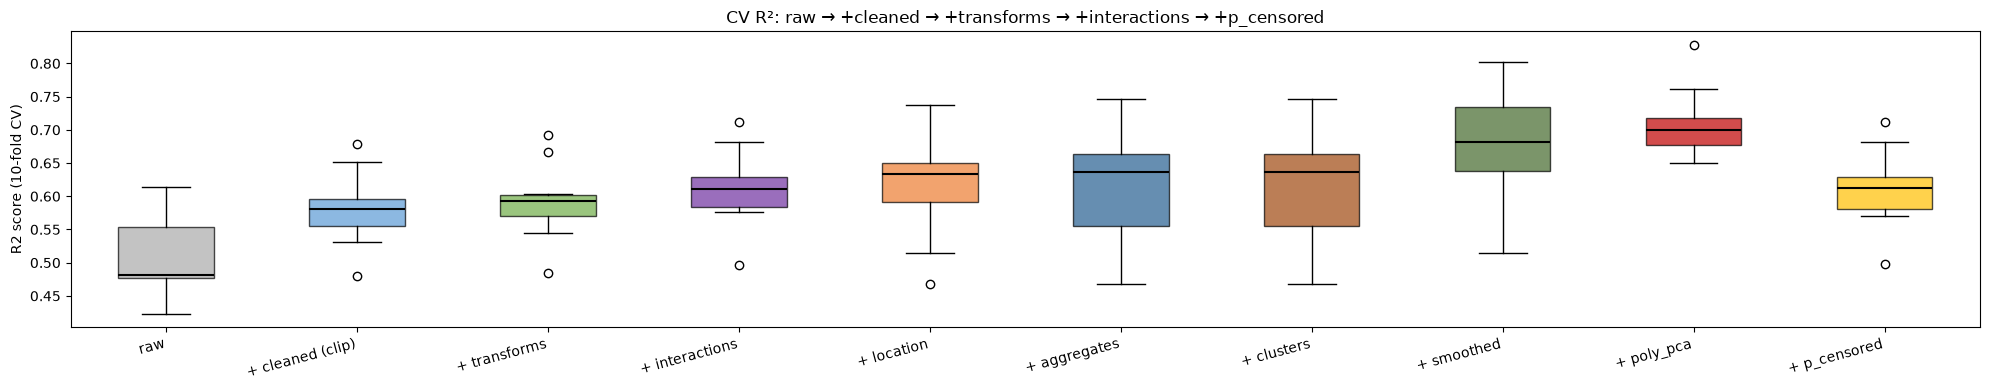

                      raw: mean R2 = 0.5110 ± 0.0593  (+0.00% vs raw)
         + cleaned (clip): mean R2 = 0.5811 ± 0.0536  (+13.71% vs raw)
             + transforms: mean R2 = 0.5923 ± 0.0551  (+15.90% vs raw)
           + interactions: mean R2 = 0.6122 ± 0.0561  (+19.81% vs raw)
               + location: mean R2 = 0.6201 ± 0.0786  (+21.34% vs raw)
             + aggregates: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)
               + clusters: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)
               + smoothed: mean R2 = 0.6810 ± 0.0777  (+33.26% vs raw)
               + poly_pca: mean R2 = 0.7104 ± 0.0490  (+39.02% vs raw)
             + p_censored: mean R2 = 0.6120 ± 0.0564  (+19.76% vs raw)


In [5]:
results_df = fl.add_pipeline_step(
    None,
    '+ p_censored',
    housing_df.drop('MedHouseVal', axis=1),
    housing_df['MedHouseVal'],
    color=PIPELINE_COLORS.get('+ p_censored', '#ffc000'),
    results_path=PIPELINE_RESULTS_PATH,
 )

fl.plot_pipeline_steps(
    results_df,
    title='CV R²: raw → +cleaned → +transforms → +interactions → +p_censored',
    results_path=PIPELINE_RESULTS_PATH,
 )

## 6. Save output

In [6]:
out_path = DATA_DIR / '05-p_censoring.csv'
housing_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/fsa-feature-engineering-challenge/05-p_censoring.csv
